# # Learning from Small Data: Challenge 3 - Evaluation Blindness
# 
# ## Using the MNIST Dataset
# 
# This notebook demonstrates the **third fundamental challenge** of learning from small data:
# 
# 1. **Unstable Cross-Validation (CV) Scores**: The validation score fluctuates massively with small validation splits.
# 2. **Unstable Hyperparameter Tuning**: The optimal regularization parameter changes drastically between different splits.
# 3. **Unreliable Feature Importance**: Feature rankings are inconsistent and irrelevant features appear important by chance.
# 
# **Key Question:** Why can't we trust our validation and selection process with small data?

In [7]:
# ## 1. Setup and Imports

# %%
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries loaded successfully!")

# ## 2. Load and Prepare MNIST Dataset

# %%
# Load MNIST (using a subset for speed)
print("Loading MNIST dataset...")
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False, parser='pandas')

# Convert to appropriate types
X = X.astype(np.float32)
y = y.astype(np.int32)

# Normalize pixel values to [0, 1]
X = X / 255.0

# Use only first 10,000 samples for faster computation
X = X[:10000]
y = y[:10000]

print(f"Dataset shape: X: {X.shape}, y: {y.shape}")
print(f"Number of classes: {len(np.unique(y))}")

# ## 3. Split Data: Train and Test

# %%
# Split into train (70%) and test (30%)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set: {X_train_full.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Libraries loaded successfully!
Loading MNIST dataset...
Dataset shape: X: (10000, 784), y: (10000,)
Number of classes: 10
Training set: 7000 samples
Test set: 3000 samples


UNSTABLE CROSS-VALIDATION EXPERIMENT


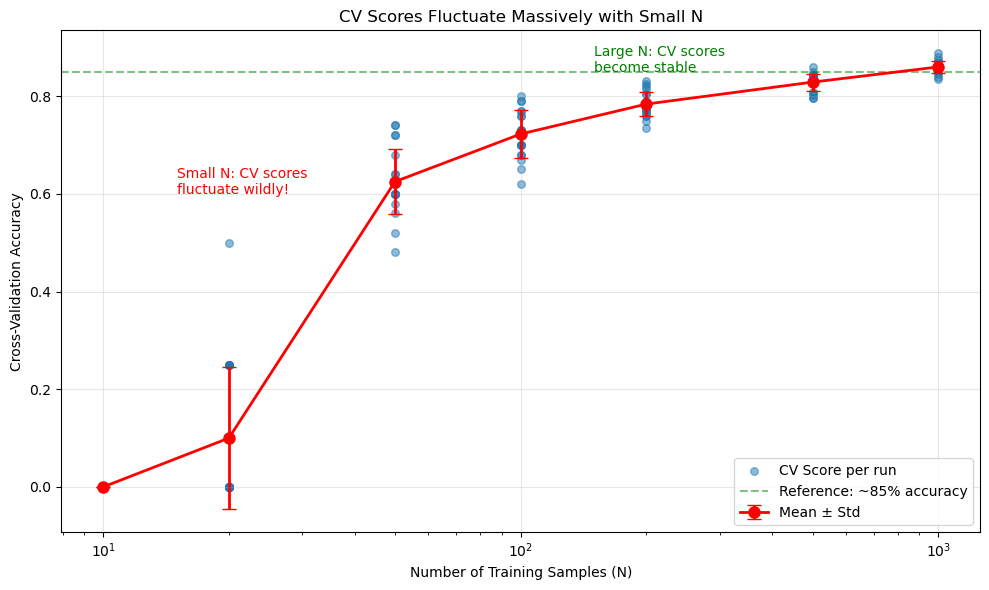


CV SCORE SUMMARY
N Size     Mean CV      Std CV       Range       
------------------------------------------------------------
10         0.000     0.000     0.000
20         0.100     0.146     0.500
50         0.625     0.067     0.260
100        0.722     0.048     0.180
200        0.784     0.025     0.095
500        0.829     0.018     0.064
1000       0.860     0.012     0.053


In [10]:
def run_cv_experiment(X_train, y_train, n_runs=20):
    """
    Run cross-validation multiple times on different random subsets.
    Returns the mean CV score and standard deviation for each run.
    """
    cv_scores = []
    train_sizes = []
    
    for run in range(n_runs):
        # Different data sizes to test
        for n_samples in [10, 20, 50, 100, 200, 500, 1000]:
            # Sample n_samples (balanced)
            n_per_class = max(1, n_samples // 10)
            indices = []
            for class_label in range(10):
                class_indices = np.where(y_train == class_label)[0]
                n_to_sample = min(n_per_class, len(class_indices))
                selected = np.random.choice(class_indices, size=n_to_sample, replace=False)
                indices.extend(selected)
            
            X_subset = X_train[indices]
            y_subset = y_train[indices]
            
            # Standardize
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X_subset)
            
            # Perform cross-validation with appropriate number of folds
            # Use leave-one-out or smaller folds for very small datasets
            n_samples_actual = len(X_subset)
            if n_samples_actual < 10:
                # Use leave-one-out
                n_folds = n_samples_actual
            elif n_samples_actual < 30:
                # Use 3 folds
                n_folds = 3
            else:
                # Use 5 folds
                n_folds = 5
            
            # Use stratified k-fold with proper number of folds
            try:
                cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
                model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
                scores = cross_val_score(model, X_scaled, y_subset, cv=cv)
                cv_scores.append(np.mean(scores))
                train_sizes.append(len(X_subset))
            except ValueError:
                # If still failing, use simple train/test split
                X_train_sub, X_val_sub, y_train_sub, y_val_sub = train_test_split(
                    X_scaled, y_subset, test_size=0.2, random_state=42
                )
                model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
                model.fit(X_train_sub, y_train_sub)
                val_acc = accuracy_score(y_val_sub, model.predict(X_val_sub))
                cv_scores.append(val_acc)
                train_sizes.append(len(X_subset))
    
    return train_sizes, cv_scores

# %% [markdown]
# ### 4.1 Run CV Experiment with Different Data Sizes

# %%
print("=" * 60)
print("UNSTABLE CROSS-VALIDATION EXPERIMENT")
print("=" * 60)

# Run the experiment
train_sizes, cv_scores = run_cv_experiment(X_train_full, y_train_full, n_runs=20)

# %% [markdown]
# ### 4.2 Visualize CV Score Instability

# %%
# Convert to numpy arrays for easier manipulation
train_sizes = np.array(train_sizes)
cv_scores = np.array(cv_scores)

# Create a scatter plot showing CV scores vs training size
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot of all runs
ax.scatter(train_sizes, cv_scores, alpha=0.5, s=30, label='CV Score per run')

# Compute and plot mean and std for each unique training size
unique_sizes = np.unique(train_sizes)
means = []
stds = []

for size in unique_sizes:
    mask = train_sizes == size
    means.append(np.mean(cv_scores[mask]))
    stds.append(np.std(cv_scores[mask]))

ax.errorbar(unique_sizes, means, yerr=stds, fmt='o-', color='red', 
            capsize=5, linewidth=2, markersize=8, label='Mean ± Std')

ax.axhline(y=0.85, color='green', linestyle='--', alpha=0.5, label='Reference: ~85% accuracy')

ax.set_xlabel('Number of Training Samples (N)')
ax.set_ylabel('Cross-Validation Accuracy')
ax.set_title('CV Scores Fluctuate Massively with Small N')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xscale('log')

# Add annotations
ax.text(15, 0.6, 'Small N: CV scores\nfluctuate wildly!', fontsize=10, color='red')
ax.text(150, 0.85, 'Large N: CV scores\nbecome stable', fontsize=10, color='green')

plt.tight_layout()
plt.savefig('cv_instability.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\n" + "=" * 60)
print("CV SCORE SUMMARY")
print("=" * 60)
print(f"{'N Size':<10} {'Mean CV':<12} {'Std CV':<12} {'Range':<12}")
print("-" * 60)
for size in unique_sizes:
    mask = train_sizes == size
    mean_cv = np.mean(cv_scores[mask])
    std_cv = np.std(cv_scores[mask])
    range_cv = np.max(cv_scores[mask]) - np.min(cv_scores[mask])
    print(f"{size:<10} {mean_cv:.3f}     {std_cv:.3f}     {range_cv:.3f}")